Accompanies Section `subsec:averaging` (Averaging Over Random Spot Parameters) of the paper.

# Averaging $|\hat{A}(\omega)|^2$ Over Random Spot Parameters

Each spot has random parameters $(t_{\rm ref}, \Lambda_{\rm ref}, \Phi_{\rm ref})$. We show how averaging the power spectral density $S_A(\omega) = |\hat{A}(\omega)|^2$ of the single-spot signal over these parameters yields the kernel, and verify each step symbolically (sympy) and numerically (Monte Carlo).

As in Section `sec:kernel_derivation`, a single spot dims the star by $\alpha_{\max}^2\,\Gamma(t)\,\mathcal{V}(t)$ (Eq. `eq:A_smallspot`), where $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$ is the normalized squared envelope (unit peak) and $\mathcal{V}(t) = \max\{\cos\beta(t),\,0\}$ is the visibility function. The constant $\alpha_{\max}^2$ passes unchanged through every Fourier transform, so we write
$$A(t) \equiv \Gamma(t)\,\mathcal{V}(t)$$
for the unit-amplitude signal and carry $\alpha_{\max}^2$ separately: the kernel of the flux is $\alpha_{\max}^4$ times the autocorrelation of $A$.

Fourier convention: $\hat f(\omega) = \int f(t)\,e^{-i\omega t}\,dt$, $f(t) = (2\pi)^{-1}\int \hat f(\omega)\,e^{i\omega t}\,d\omega$, and Wiener–Khinchin (Eq. `eq:wk`) $R_f(\tau) = \int f(t)\,f(t+\tau)\,dt = (2\pi)^{-1}\int |\hat f(\omega)|^2 e^{i\omega\tau}\,d\omega$.

**Result** (Eqs. `eq:kernel_complex`, `eq:kernel_single_spot`): the single-spot kernel factorizes as
$$\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau) \sum_n |c_n|^2 \, e^{in\omega_0 \tau} = \alpha_{\max}^4\, R_\Gamma(\tau)\left[|c_0|^2 + 2\sum_{n\ge1}|c_n|^2\cos(n\omega_0\tau)\right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from spotgp.envelope import _Gamma_hat, _R_Gamma_symmetric
from spotgp.visibility import _cn_general_jax

sp.init_printing()

## 1. Single-Spot Signal With Random Parameters

From the small-spot approximation (Eq. `eq:A_smallspot`), with $\alpha_{\max}^2$ carried separately:
$$A(t) = \Gamma(t - t_{\rm ref}) \cdot \mathcal{V}(t;\, t_{\rm ref}, \Lambda_{\rm ref}, \Phi_{\rm ref})$$

where $\mathcal{V}(t) = \max\{\cos\beta(t),\, 0\}$ with (Eq. `eq:cos_beta`)
$$\cos\beta(t) = b_0 + b_1 \cos\Lambda(t), \qquad b_0 = \cos I\sin\Phi, \quad b_1 = \sin I\cos\Phi,$$
and the spot longitude advances from its value $\Lambda_{\rm ref}$ at the reference time $t_{\rm ref}$ (Section "Latitudinal and Longitudinal Evolution of Spots"):
$$\Lambda(t) = \Lambda_{\rm ref} + \omega_0\,(t - t_{\rm ref}).$$

The three random parameters enter as follows.

### Effect of $t_{\rm ref}$: time shift

Because $\Lambda_{\rm ref}$ is the longitude *at* $t_{\rm ref}$, changing $t_{\rm ref}$ shifts the whole signal, $A(t) = A_0(t - t_{\rm ref})$, where $A_0$ is the same spot with $t_{\rm ref} = 0$. For the envelope, $\Gamma(t) \to \Gamma(t - t_{\rm ref})$ gives the phase factor (property `ft:timeshift`)
$$\hat{\Gamma}(\omega;\, t_{\rm ref}) = \hat{\Gamma}(\omega)\, e^{-i\omega t_{\rm ref}},$$
and the same overall phase $e^{-i\omega t_{\rm ref}}$ multiplies $\hat A(\omega)$. It **cancels** in $|\hat{A}(\omega)|^2$, so $t_{\rm ref}$ drops out entirely.

(If the longitude were instead fixed at $t = 0$, $\Lambda(t) = \Lambda_0 + \omega_0 t$, then $\Lambda_{\rm ref} = \Lambda_0 + \omega_0 t_{\rm ref}$, and the power spectrum of an individual spot would depend on $t_{\rm ref}$ through this combination. The average over a uniform longitude is the same either way; both cases are checked numerically in Section 5.)

### Effect of $\Lambda_{\rm ref}$: phase shift of the visibility

Shifting $\Lambda_{\rm ref}$ is equivalent to a time shift of $\Lambda_{\rm ref}/\omega_0$ in the periodic visibility function, so its Fourier series coefficients pick up a harmonic-dependent phase (Eq. `eq:cn_phase`):
$$c_n(\Lambda_{\rm ref}) = c_n\, e^{in\Lambda_{\rm ref}}, \qquad c_n \equiv c_n(\Lambda_{\rm ref} = 0).$$

### Effect of $\Phi_{\rm ref}$: changes $c_n$ and $\omega_0$

The latitude $\Phi \in [-\pi/2, \pi/2]$ sets the Fourier coefficients $c_n$ (Eq. `eq:cn_general`) through $b_0$, $b_1$ and the visibility half-window $\theta_{\rm vis} = \arccos(-b_0/b_1)$, and sets the rotation frequency through differential rotation, $\omega_0(\Phi) = 2\pi(1 - \kappa\sin^2\Phi)/P_{\rm eq}$. It is averaged over $p(\Phi)$ in Section `subsec:multi_spot` (see the summary at the end).

## 2. Power Spectral Density

By the multiplication property (`ft:multiplication`), the FT of the product $A = \Gamma\,\mathcal{V}$ is
$$\hat{A}(\omega) = \frac{1}{2\pi}\Big[\hat{\Gamma}(\omega)\, e^{-i\omega t_{\rm ref}}\Big] \ast \hat{\mathcal{V}}(\omega;\, \Lambda_{\rm ref}).$$

Using $\hat{\mathcal{V}}(\omega) = 2\pi \sum_n c_n\, e^{in\Lambda_{\rm ref}}\, \delta(\omega - n\omega_0)$ (Eq. `eq:cap_hat` with the phases of Eq. `eq:cn_phase`) and the sifting property gives Eq. `eq:A_hat_random`:
$$\hat{A}(\omega) = e^{-i\omega t_{\rm ref}} \sum_n c_n\, e^{in\Lambda_{\rm ref}}\, \hat{\Gamma}(\omega - n\omega_0)$$

(Eq. `eqn:ft_At` in the paper writes $\hat A = \hat\Gamma \ast \hat{\mathcal{V}}$ without the $1/(2\pi)$ of property `ft:multiplication`; the $1/(2\pi)$ is what cancels the $2\pi$ of Eq. `eq:cap_hat` to give Eq. `eq:A_hat_sum`. The numerical check in Section 5 confirms the absolute normalization of Eq. `eq:A_hat_sum`.)

The power spectral density is (Eq. `eq:esd_double_sum`):
$$|\hat{A}(\omega)|^2 = \sum_n \sum_m c_n\, c_m^* \, e^{i(n-m)\Lambda_{\rm ref}} \, \hat{\Gamma}(\omega - n\omega_0)\, \hat{\Gamma}^*(\omega - m\omega_0)$$

Note that $|e^{-i\omega t_{\rm ref}}|^2 = 1$, confirming that $t_{\rm ref}$ drops out.

In [2]:
# Symbolic check that the t_ref phase drops out of |A_hat|^2
omega, t_ref_s = sp.symbols('omega t_ref', real=True)

phase_tref = sp.exp(-sp.I * omega * t_ref_s)
mod2 = sp.simplify(sp.Abs(phase_tref)**2)
print("|exp(-i omega t_ref)|^2 =", mod2)
assert mod2 == 1

|exp(-i omega t_ref)|^2 = 1


## 3. Averaging Over $\Lambda_{\rm ref}$

If $\Lambda_{\rm ref}$ is uniformly distributed on $[0, 2\pi]$ (Eq. `eq:longitude_orthogonality`):
$$\left\langle e^{i(n-m)\Lambda_{\rm ref}} \right\rangle_{\Lambda_{\rm ref}} = \frac{1}{2\pi} \int_0^{2\pi} e^{i(n-m)\Lambda_{\rm ref}}\, d\Lambda_{\rm ref} = \delta_{nm}$$

This **cancels all cross terms** between different harmonics:

In [3]:
# Symbolic verification of the orthogonality integral
k_sym = sp.symbols('k', integer=True, nonzero=True)
Lam = sp.symbols('Lambda_ref', real=True)

avg_nonzero = sp.simplify(sp.integrate(sp.exp(sp.I * k_sym * Lam), (Lam, 0, 2*sp.pi)) / (2*sp.pi))
avg_zero = sp.integrate(1, (Lam, 0, 2*sp.pi)) / (2*sp.pi)
print("<exp(i k Lambda_ref)> for integer k != 0:", avg_nonzero)
print("<exp(i 0 Lambda_ref)> = <1>:            ", avg_zero)
assert avg_nonzero == 0 and avg_zero == 1

<exp(i k Lambda_ref)> for integer k != 0: 0
<exp(i 0 Lambda_ref)> = <1>:             1


Therefore, averaging $|\hat{A}(\omega)|^2$ over uniform $\Lambda_{\rm ref}$ (Eq. `eq:esd_averaged`):

$$\boxed{\left\langle |\hat{A}(\omega)|^2 \right\rangle_{t_{\rm ref},\, \Lambda_{\rm ref}} = \sum_n |c_n|^2 \, S_\Gamma(\omega - n\omega_0)}, \qquad S_\Gamma(\omega) \equiv |\hat{\Gamma}(\omega)|^2$$

Each harmonic contributes independently: the random longitude averages away all interference between harmonics. The cell below checks this on the full double sum, truncated at $|n|, |m| \le 2$, with $\hat\Gamma_n \equiv \hat\Gamma(\omega - n\omega_0)$ left as arbitrary complex numbers and real $c_{-n} = c_n$.

In [4]:
# Symbolic check of Eq. eq:esd_double_sum -> eq:esd_averaged, truncated at |n| <= 2
N_s = 2
ns = range(-N_s, N_s + 1)
c_s = {n: sp.Symbol(f'c_{abs(n)}', real=True) for n in ns}            # real, c_{-n} = c_n
G_s = {n: sp.Symbol(r'\hat{\Gamma}_{%d}' % n) for n in ns}           # Gamma_hat(omega - n omega_0), complex

A_hat_s = sp.exp(-sp.I * omega * t_ref_s) * sum(c_s[n] * sp.exp(sp.I * n * Lam) * G_s[n] for n in ns)
S_A_s = sp.powsimp(sp.expand(A_hat_s * sp.conjugate(A_hat_s)))   # Eq. eq:esd_double_sum (t_ref phase cancels)
S_avg_s = sp.integrate(S_A_s, (Lam, 0, 2*sp.pi)) / (2*sp.pi)
S_expected = sum(c_s[n]**2 * G_s[n] * sp.conjugate(G_s[n]) for n in ns)

print(f"double sum: {len(sp.Add.make_args(S_A_s))} terms before averaging, "
      f"{len(sp.Add.make_args(sp.expand(S_avg_s)))} (the n = m terms) after")
assert sp.simplify(S_avg_s - S_expected) == 0
display(sp.Eq(sp.Symbol(r'\langle|\hat{A}|^2\rangle'), sp.expand(S_avg_s)))

double sum: 25 terms before averaging, 5 (the n = m terms) after


## 4. The Kernel via Wiener–Khinchin

The kernel is $\alpha_{\max}^4$ times the inverse FT of the averaged power spectral density of $A$:
$$\mathcal{K}(\tau) = \frac{\alpha_{\max}^4}{2\pi} \int_{-\infty}^{\infty} \left\langle |\hat{A}(\omega)|^2 \right\rangle \, e^{i\omega\tau}\, d\omega$$

Substituting the diagonal sum:
$$\mathcal{K}(\tau) = \alpha_{\max}^4 \sum_n |c_n|^2 \cdot \frac{1}{2\pi} \int_{-\infty}^{\infty} S_\Gamma(\omega - n\omega_0) \, e^{i\omega\tau}\, d\omega$$

Shifting $u = \omega - n\omega_0$:
$$\frac{1}{2\pi} \int S_\Gamma(u) \, e^{i(u + n\omega_0)\tau}\, du = e^{in\omega_0\tau} \cdot R_\Gamma(\tau)$$

where $R_\Gamma(\tau) = \frac{1}{2\pi} \int S_\Gamma(\omega) \, e^{i\omega\tau}\, d\omega = \int \Gamma(t)\,\Gamma(t+\tau)\,dt$ is the autocorrelation of the normalized squared envelope $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$.

Therefore (Eq. `eq:kernel_complex`):
$$\boxed{\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau) \sum_{n=-\infty}^{\infty} |c_n|^2 \, e^{in\omega_0\tau}}$$

Since $c_{-n} = c_n$ (all real), this simplifies to (Eq. `eq:kernel_single_spot`):
$$\boxed{\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau) \left[ |c_0|^2 + 2\sum_{n=1}^{\infty} |c_n|^2 \cos(n\omega_0\tau) \right]}$$

**The kernel is the product of the envelope autocorrelation and a sum of cosines weighted by the squared Fourier coefficients of the visibility function.**

In [5]:
# Symbolic verification: the complex-exponential sum is the real cosine sum (2nd order, Eq. eq:kernel_truncated)
tau_sym = sp.symbols('tau', real=True)
omega0_sym = sp.symbols('omega_0', positive=True)
c0, c1, c2 = sp.symbols('c_0 c_1 c_2', real=True)
c_sym = {0: c0, 1: c1, 2: c2}

kernel_sum = sum(c_sym[abs(n)]**2 * sp.exp(sp.I * n * omega0_sym * tau_sym) for n in range(-2, 3))
cos_form = c0**2 + 2*c1**2*sp.cos(omega0_sym*tau_sym) + 2*c2**2*sp.cos(2*omega0_sym*tau_sym)

assert sp.simplify(kernel_sum.rewrite(sp.cos) - cos_form) == 0
display(sp.Eq(kernel_sum, cos_form))

## 5. Numerical Verification of the Averaged Power Spectral Density

We verify the averaging by:
1. Building $A(t) = \Gamma(t)\,\mathcal{V}(t)$ with $\Gamma$ the normalized squared trapezoid (plateau $\ell_{\rm spot}$, ramps $\tau_{\rm spot}$), and checking the closed-form $\hat\Gamma(\omega)$ of Eq. `eq:Gamma_hat` against the FFT of the sampled $\Gamma(t)$;
2. Checking that, for one spot, $|\hat A(\omega)|^2$ does not depend on $t_{\rm ref}$;
3. Computing $|\hat{A}(\omega)|^2$ for many random $(t_{\rm ref}, \Lambda_{\rm ref})$ and averaging them;
4. Comparing to the analytic result $\sum_n |c_n|^2\, S_\Gamma(\omega - n\omega_0)$ of Eq. `eq:esd_averaged`, with $\hat\Gamma$ from Eq. `eq:Gamma_hat`, in absolute units (no fitted normalization).

In [6]:
# --- Parameters: one latitude, solid-body rotation ---
P_eq = 5.0                 # equatorial rotation period [days]
kappa = 0.0                # differential-rotation shear (solid body)
inc = np.pi / 2            # stellar inclination I (edge-on)
Phi = np.radians(60)       # spot latitude, Phi in [-pi/2, pi/2]
omega_0 = 2 * np.pi * (1 - kappa * np.sin(Phi)**2) / P_eq
ell_spot = 20.0            # plateau duration [days]
tau_spot = 5.0             # emergence = decay ramp time [days]
alpha_max = 0.1            # peak spot angular radius [rad] (~6 deg)
N_harm = 50                # harmonics kept in the analytic sums

b0 = np.cos(inc) * np.sin(Phi)
b1 = np.sin(inc) * np.cos(Phi)

# Fourier coefficients c_n of V(t) (Eq. eq:cn_general), real with c_{-n} = c_n
cn = np.array([float(_cn_general_jax(n, inc, Phi)) for n in range(N_harm + 1)])

# Edge-on check (Eq. eq:cn_edgeon): c_n = g_n cos(Phi) with g_0 = 1/pi, g_1 = 1/4, g_2 = 1/(3 pi)
g_n = np.array([1/np.pi, 1/4, 1/(3*np.pi)])
assert np.allclose(cn[:3], g_n * np.cos(Phi), rtol=0, atol=1e-12)

print(f"Fourier coefficients for I={np.degrees(inc):.0f} deg, Phi={np.degrees(Phi):.0f} deg:")
for n in range(5):
    print(f"  c_{n} = {cn[n]: .6f},  |c_{n}|^2 = {cn[n]**2:.6f}")

Fourier coefficients for I=90 deg, Phi=60 deg:
  c_0 =  0.159155,  |c_0|^2 = 0.025330
  c_1 =  0.125000,  |c_1|^2 = 0.015625
  c_2 =  0.053052,  |c_2|^2 = 0.002814
  c_3 = -0.000000,  |c_3|^2 = 0.000000
  c_4 = -0.010610,  |c_4|^2 = 0.000113


In [7]:
# --- Time grid, envelope and visibility ---
N_t = 2**14        # FFT size
T_obs = 200.0      # window [days]; the spot (support ell_spot + 2 tau_spot = 30 d) sits well inside
dt = T_obs / N_t
t = np.arange(N_t) * dt
omega = 2 * np.pi * np.fft.fftfreq(N_t, d=dt)   # angular frequency grid
lag = np.arange(N_t) * dt                       # lag grid for autocorrelations


def alpha_trap(t, t_ref):
    # Symmetric trapezoid alpha(t) (Eq. eqn:trapezoid, tau_em = tau_dec = tau_spot): plateau ell_spot, peak alpha_max
    return alpha_max * np.clip((ell_spot/2 + tau_spot - np.abs(t - t_ref)) / tau_spot, 0.0, 1.0)


def Gamma(t, t_ref):
    # Normalized squared envelope Gamma(t) = alpha^2(t) / alpha_max^2 (unit peak)
    return (alpha_trap(t, t_ref) / alpha_max)**2


def visibility(t, t_ref, Lambda_ref):
    # V(t) = max{cos beta, 0}, cos beta = b0 + b1 cos Lambda(t), Lambda(t) = Lambda_ref + omega_0 (t - t_ref)
    return np.maximum(b0 + b1 * np.cos(Lambda_ref + omega_0 * (t - t_ref)), 0.0)


def ft(f):
    # Riemann-sum approximation of f_hat(omega) = int f(t) exp(-i omega t) dt on the FFT grid
    return np.fft.fft(f) * dt


# Closed-form Gamma_hat (Eq. eq:Gamma_hat) vs. FFT of the sampled Gamma(t); compare moduli because the
# sampled envelope is centred at T_obs/2, which only adds a phase
Gamma_hat_0 = np.asarray(_Gamma_hat(omega, ell_spot, tau_spot))
err_Gh = np.max(np.abs(np.abs(ft(Gamma(t, T_obs/2))) - np.abs(Gamma_hat_0))) / Gamma_hat_0[0]
print(f"Gamma_hat(0) = {Gamma_hat_0[0]:.4f}  (ell_spot + 2 tau_spot / 3 = {ell_spot + 2*tau_spot/3:.4f})")
print(f"max |FFT - Eq. eq:Gamma_hat| / Gamma_hat(0) = {err_Gh:.1e}")
assert err_Gh < 1e-5   # observed 4.6e-7: O(dt^2) rectangle-rule error of the sampled Gamma(t)

Gamma_hat(0) = 23.3333  (ell_spot + 2 tau_spot / 3 = 23.3333)
max |FFT - Eq. eq:Gamma_hat| / Gamma_hat(0) = 4.6e-07


In [8]:
# --- t_ref drops out of |A_hat|^2 for each spot ---
Lam_test, t_a, t_b = 1.3, 60.0, 123.4567
S_a = np.abs(ft(Gamma(t, t_a) * visibility(t, t_a, Lam_test)))**2
S_b = np.abs(ft(Gamma(t, t_b) * visibility(t, t_b, Lam_test)))**2
d_ref = np.max(np.abs(S_a - S_b)) / S_a.max()

# Longitude fixed at t = 0 instead (Lambda(t) = Lambda_0 + omega_0 t): the spectrum of an individual spot
# changes with t_ref, because then Lambda_ref = Lambda_0 + omega_0 t_ref
S_a0 = np.abs(ft(Gamma(t, t_a) * visibility(t, 0.0, Lam_test)))**2
S_b0 = np.abs(ft(Gamma(t, t_b) * visibility(t, 0.0, Lam_test)))**2
d_t0 = np.max(np.abs(S_a0 - S_b0)) / S_a0.max()

print(f"Lambda_ref at t_ref: max |S(t_ref={t_a}) - S(t_ref={t_b})| / max S = {d_ref:.1e}")
print(f"Lambda_0 at t = 0:   max |S(t_ref={t_a}) - S(t_ref={t_b})| / max S = {d_t0:.1e}")
assert d_ref < 1e-4   # observed 4e-6: the non-integer shift re-samples the kinks of A(t) on the grid
assert d_t0 > 1e-2    # observed 4.5e-2: a real change, removed only by the average over Lambda

Lambda_ref at t_ref: max |S(t_ref=60.0) - S(t_ref=123.4567)| / max S = 4.1e-06
Lambda_0 at t = 0:   max |S(t_ref=60.0) - S(t_ref=123.4567)| / max S = 4.5e-02


In [9]:
# --- Monte Carlo over random (t_ref, Lambda_ref) at fixed latitude ---
N_samples = 2000
rng = np.random.default_rng(42)

S_sum = np.zeros(N_t); S_sq = np.zeros(N_t)   # PSD of the unit-amplitude signal A = Gamma V
K_sum = np.zeros(N_t); K_sq = np.zeros(N_t)   # autocorrelation of the flux deficit alpha^2 V = alpha_max^2 A

for _ in range(N_samples):
    t_ref = rng.uniform(30, 170)             # keep the 30-day envelope inside the window
    Lambda_ref = rng.uniform(0, 2*np.pi)

    alpha_t = alpha_trap(t, t_ref)
    V_t = visibility(t, t_ref, Lambda_ref)
    A_t = (alpha_t / alpha_max)**2 * V_t     # A(t) = Gamma(t) V(t)

    S_A = np.abs(ft(A_t))**2
    S_sum += S_A; S_sq += S_A**2

    # Brute-force R(tau) = int dF(t) dF(t + tau) dt of the flux deficit, exact on the grid (circular
    # correlation via FFT; no wrap-around for lags < T_obs - 30 d)
    dF_t = alpha_t**2 * V_t
    R_dF = np.fft.ifft(np.abs(ft(dF_t))**2).real / dt
    K_sum += R_dF; K_sq += R_dF**2


def mean_and_se(s, s2, n):
    # Sample mean and its Monte Carlo standard error
    m = s / n
    return m, np.sqrt(np.maximum(s2 / n - m**2, 0.0) / (n - 1))


S_num, S_se = mean_and_se(S_sum, S_sq, N_samples)
K_num, K_se = mean_and_se(K_sum, K_sq, N_samples)
print(f"Averaged |A_hat(omega)|^2 and the flux autocorrelation over {N_samples} random (t_ref, Lambda_ref) samples.")

Averaged |A_hat(omega)|^2 and the flux autocorrelation over 2000 random (t_ref, Lambda_ref) samples.


max |numerical - analytic| / peak      = 2.3e-04
max MC standard error / peak           = 1.1e-03
max |numerical - analytic| / std. error = 2.15  over 201 frequencies


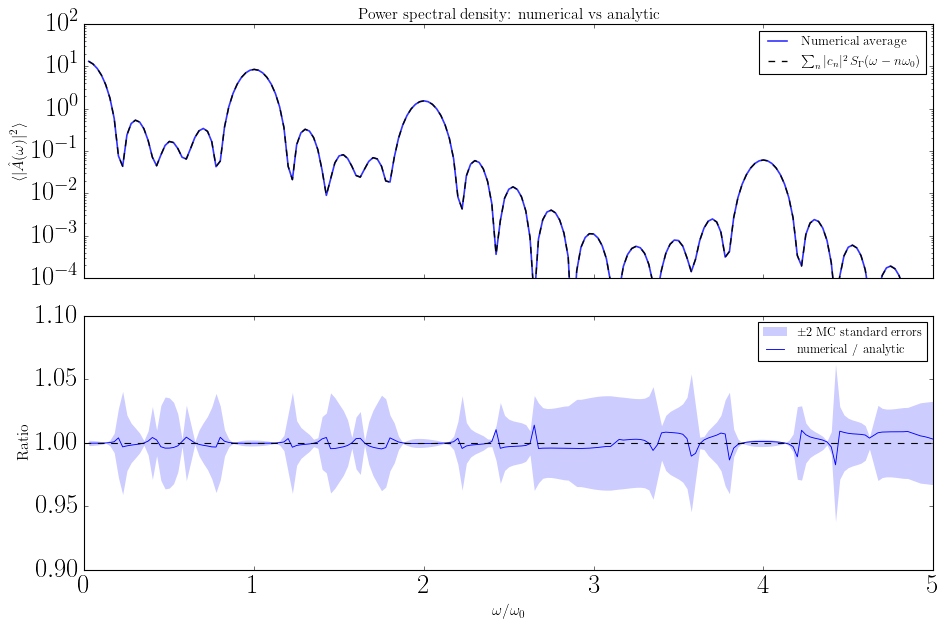

In [10]:
# --- Analytic prediction (Eq. eq:esd_averaged): sum_n |c_n|^2 S_Gamma(omega - n omega_0) ---
S_ana = np.zeros(N_t)
for n in range(-N_harm, N_harm + 1):
    S_ana += cn[abs(n)]**2 * np.asarray(_Gamma_hat(omega - n*omega_0, ell_spot, tau_spot))**2

band = (omega >= 0) & (omega <= 5*omega_0)
err_S = np.abs(S_num - S_ana)
z_S = err_S[band] / S_se[band]
print(f"max |numerical - analytic| / peak      = {err_S[band].max() / S_ana.max():.1e}")
print(f"max MC standard error / peak           = {S_se[band].max() / S_ana.max():.1e}")
print(f"max |numerical - analytic| / std. error = {z_S.max():.2f}  over {band.sum()} frequencies")

# Tolerance from the Monte Carlo noise. The per-spot spectrum scatters through the Lambda_ref cross terms, with
# standard error S_se(omega) of the mean (at most 1.1e-3 of the peak for N = 2000, falling as 1/sqrt(N)).
# Observed: max error 2.3e-4 of the peak and max |error| / S_se = 2.2 over the band (seed 42; other seeds give
# 1.4-2.2), i.e. consistent with pure MC noise. We require every frequency to lie within 5 standard errors,
# plus a 1e-5 floor for the grid error (4.6e-7, see the Gamma_hat check). A wrong normalization (e.g. a
# missing 2 pi), envelope (alpha instead of Gamma) or surviving cross terms would give errors of order unity.
assert np.all(err_S[band] <= 5*S_se[band] + 1e-5*S_ana.max())

# --- Plot comparison ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

pos = (omega > 0) & (omega <= 5*omega_0)
w_plot = omega[pos] / omega_0   # in units of omega_0

ax1.semilogy(w_plot, S_num[pos], 'C0-', lw=1.5, alpha=0.8, label='Numerical average')
ax1.semilogy(w_plot, S_ana[pos], 'k--', lw=1.2, label=r'$\sum_n |c_n|^2\, S_\Gamma(\omega - n\omega_0)$')
ax1.set_ylabel(r'$\langle|\hat{A}(\omega)|^2\rangle$', fontsize=14)
ax1.set_title('Power spectral density: numerical vs analytic', fontsize=14)
ax1.legend(fontsize=12)
ax1.set_ylim(bottom=1e-4)

# Ratio, with the +-2 standard-error band of the Monte Carlo average
valid = S_ana[pos] > 1e-6 * S_ana.max()
rel_se = S_se[pos][valid] / S_ana[pos][valid]
ax2.fill_between(w_plot[valid], 1 - 2*rel_se, 1 + 2*rel_se, color='C0', alpha=0.2, lw=0,
                 label=r'$\pm 2$ MC standard errors')
ax2.plot(w_plot[valid], S_num[pos][valid] / S_ana[pos][valid], 'C0-', lw=0.8, label='numerical / analytic')
ax2.axhline(1, color='k', ls='--', lw=1)
ax2.set_xlabel(r'$\omega / \omega_0$', fontsize=14)
ax2.set_ylabel('Ratio', fontsize=14)
ax2.set_xlim(0, 5)
ax2.set_ylim(0.9, 1.1)
ax2.legend(fontsize=11)

fig.tight_layout()
plt.show()

## 6. Kernel in the Time Domain

The single-spot kernel is (Eq. `eq:kernel_single_spot`)
$$\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau) \left[ |c_0|^2 + 2\sum_{n=1}^{N} |c_n|^2 \cos(n\omega_0\tau) \right]$$

where $R_\Gamma(\tau)$ is the closed-form autocorrelation of the normalized squared trapezoid (Appendix `app:acf_trapezoid`, `spotgp.envelope._R_Gamma_symmetric`). We compare it with the brute-force average of $\int \delta F(t)\,\delta F(t+\tau)\,dt$ for the single-spot flux deficit $\delta F(t) = \alpha^2(t)\,\mathcal{V}(t) = \alpha_{\max}^2 A(t)$, computed from the same Monte Carlo draws; this also checks the $\alpha_{\max}^4$ prefactor.

In [11]:
# --- Analytic kernel (Eq. eq:kernel_single_spot) ---
R_Gamma = np.asarray(_R_Gamma_symmetric(lag, ell_spot, tau_spot))


def kernel_analytic(lag, R_Gamma, cn, omega_0):
    # K(tau) = alpha_max^4 R_Gamma(tau) [|c_0|^2 + 2 sum_n |c_n|^2 cos(n omega_0 tau)]
    cosine_sum = cn[0]**2 * np.ones_like(lag)
    for n in range(1, len(cn)):
        cosine_sum += 2 * cn[n]**2 * np.cos(n * omega_0 * lag)
    return alpha_max**4 * R_Gamma * cosine_sum


K_ana = kernel_analytic(lag, R_Gamma, cn, omega_0)

max_lag = 8   # rotation periods shown / tested
in_range = lag <= max_lag * P_eq
err_K = np.abs(K_num - K_ana)[in_range]
print(f"K(0): analytic = {K_ana[0]:.6e}, numerical = {K_num[0]:.6e}")
print(f"max |numerical - analytic| / K(0) = {err_K.max() / K_ana[0]:.1e}")
print(f"max MC standard error / K(0)      = {K_se[in_range].max() / K_ana[0]:.1e}")

# Tolerance from the Monte Carlo noise, as for the spectrum: within 5 standard errors at every lag up to 8 P.
# Observed: max error 2.3e-4 of K(0) against a standard error of up to 1.1e-3 of K(0). At tau = (k + 1/2) P the
# edge-on spot is never visible at both t and t + tau, so every sample gives exactly 0 (zero standard error);
# there the residual, 5e-7 of K(0), is grid plus harmonic-truncation error, covered by a 1e-5 K(0) floor.
assert np.all(err_K <= 5*K_se[in_range] + 1e-5*K_ana[0])

K(0): analytic = 1.374999e-04, numerical = 1.374678e-04
max |numerical - analytic| / K(0) = 2.3e-04
max MC standard error / K(0)      = 1.1e-03


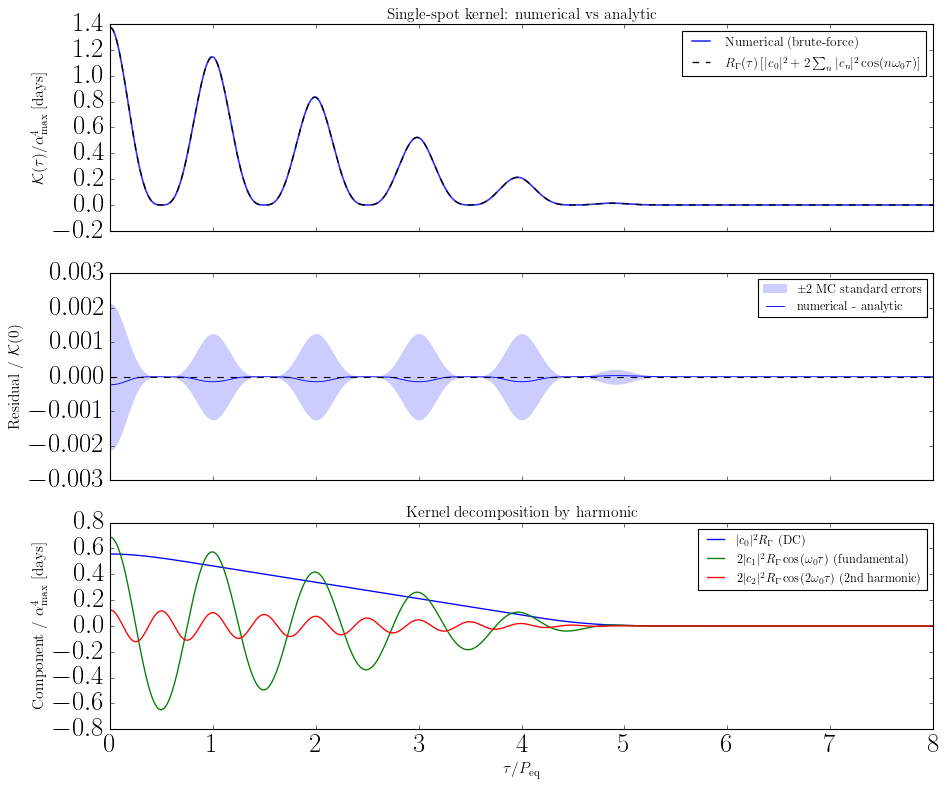

In [12]:
# --- Plot kernel comparison ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

tau_plot = lag / P_eq   # in units of the rotation period
m = in_range

# Kernels shown in units of alpha_max^4 (the brute-force curve is the flux-deficit autocorrelation / alpha_max^4)
ax1.plot(tau_plot[m], K_num[m] / alpha_max**4, 'C0-', lw=1.5, alpha=0.8, label='Numerical (brute-force)')
ax1.plot(tau_plot[m], K_ana[m] / alpha_max**4, 'k--', lw=1.2,
         label=r'$R_\Gamma(\tau) \left[|c_0|^2 + 2\sum_n |c_n|^2 \cos(n\omega_0\tau)\right]$')
ax1.set_ylabel(r'$\mathcal{K}(\tau) / \alpha_{\max}^4$ [days]', fontsize=14)
ax1.set_title('Single-spot kernel: numerical vs analytic', fontsize=14)
ax1.legend(fontsize=12)

ax2.fill_between(tau_plot[m], -2*K_se[m]/K_ana[0], 2*K_se[m]/K_ana[0], color='C0', alpha=0.2, lw=0,
                 label=r'$\pm 2$ MC standard errors')
ax2.plot(tau_plot[m], (K_num[m] - K_ana[m]) / K_ana[0], 'C0-', lw=0.8, label='numerical - analytic')
ax2.axhline(0, color='k', ls='--', lw=1)
ax2.set_ylabel(r'Residual / $\mathcal{K}(0)$', fontsize=14)
ax2.legend(fontsize=11)

# Decompose into harmonic components
ax3.plot(tau_plot[m], R_Gamma[m] * cn[0]**2, 'C0-', lw=1.2,
         label=r'$|c_0|^2 R_\Gamma$  (DC)')
ax3.plot(tau_plot[m], R_Gamma[m] * 2*cn[1]**2 * np.cos(omega_0*lag[m]), 'C1-', lw=1.2,
         label=r'$2|c_1|^2 R_\Gamma \cos(\omega_0\tau)$  (fundamental)')
ax3.plot(tau_plot[m], R_Gamma[m] * 2*cn[2]**2 * np.cos(2*omega_0*lag[m]), 'C2-', lw=1.2,
         label=r'$2|c_2|^2 R_\Gamma \cos(2\omega_0\tau)$  (2nd harmonic)')
ax3.set_xlabel(r'$\tau / P_{\rm eq}$', fontsize=14)
ax3.set_ylabel(r'Component / $\alpha_{\max}^4$ [days]', fontsize=14)
ax3.set_title('Kernel decomposition by harmonic', fontsize=14)
ax3.legend(fontsize=11)
ax3.set_xlim(0, max_lag)

fig.tight_layout()
plt.show()

## 7. Summary

### What each random parameter does:

| Parameter | Effect on $\hat{A}(\omega)$ | Effect on $\lvert\hat{A}(\omega)\rvert^2$ |
|-----------|----------------------------|----------------------------------|
| $t_{\rm ref}$ | Phase $e^{-i\omega t_{\rm ref}}$ | **Drops out** ($\lvert e^{i\phi}\rvert^2 = 1$) |
| $\Lambda_{\rm ref}$ | Phase $e^{in\Lambda_{\rm ref}}$ on each $c_n$ | **Cancels cross terms** ($n \neq m$) |
| $\Phi_{\rm ref}$ | Changes $c_n$, $\omega_0$ | Enters as $\lvert c_n(\Phi)\rvert^2$; integrate over $p(\Phi)$ |

### Final single-spot kernel (fixed latitude), Eq. `eq:kernel_truncated`:
$$\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau) \left[ |c_0|^2 + 2|c_1|^2 \cos(\omega_0\tau) + 2|c_2|^2 \cos(2\omega_0\tau) + \cdots \right]$$

### With latitude averaging (and differential rotation), Eq. `eq:kernel_lat_avg`:
$$\langle\mathcal{K}(\tau)\rangle_\Phi = \alpha_{\max}^4 \int_{-\pi/2}^{\pi/2} R_\Gamma(\tau) \left[ |c_0(\Phi)|^2 + 2\sum_{n=1}^{N} |c_n(\Phi)|^2 \cos\!\big(n\omega_0(\Phi)\,\tau\big) \right] p(\Phi)\, d\Phi$$

where $\omega_0(\Phi) = 2\pi(1 - \kappa\sin^2\Phi) / P_{\rm eq}$ accounts for differential rotation. For a population of spots emerging at rate $\dot N_{\rm spot}$ with contrast $f_{\rm spot}$, the GP kernel is $\dot N_{\rm spot}(1 - f_{\rm spot})^2\langle\mathcal{K}(\tau)\rangle_\Phi$ (Eqs. `eq:kernel_Nspot`, `eq:kernel_full`), with amplitude $\sigma_k^2 = \dot N_{\rm spot}(1 - f_{\rm spot})^2\alpha_{\max}^4$.